# Aula 05 — Inferência Estatística
**Ciência de Dados · Univassouras · Prof. Mesc. Diego Ramos Inácio**

---

Este notebook acompanha a apresentação da Aula 05. Você vai encontrar:

| # | Conteúdo |
|---|----------|
| 1 | Configuração do ambiente |
| 2 | **Exemplo 1** — Teorema Central do Limite (TCL) |
| 3 | **Exemplo 2** — Erro padrão e intervalo de confiança para a média |
| 4 | **Exemplo 3** — Intervalo de confiança para proporção |
| 5 | **Exemplo 4** — Teste t de duas amostras independentes |
| 6 | **Exemplo 5** — Teste t pareado (antes/depois) |
| 7 | **Exemplo 6** — ANOVA + post-hoc Tukey HSD |
| 8 | **Exemplo 7** — Qui-quadrado de independência |
| 9 | **Exemplo 8** — Teste A/B de proporções + poder estatístico |
| 10 | Mapa rápido de testes |
| 11 | **Exercício** — sua vez! |

> **Dica:** execute cada célula com `Shift + Enter`, na ordem.

## 0 · Configuração do Ambiente

Instale as dependências caso ainda não tenha (remova o `#` e execute).

In [33]:
# !pip install numpy pandas matplotlib scipy statsmodels --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('Ambiente pronto!')

Ambiente pronto!


---
## 1 · Exemplo 1 — Teorema Central do Limite (TCL)
### Problema: a média de amostras vira Normal mesmo quando a população não é

**Ideia central:** independente da distribuição da população, a distribuição das **médias amostrais** se aproxima de uma Normal conforme `n` cresce (geralmente `n >= 30`).

> **Por que importa:** é o que justifica usar intervalos de confiança e testes z/t mesmo quando os dados originais não seguem uma Normal.

In [3]:
# ── População fortemente assimétrica (exponencial) ─────────────
populacao = np.random.exponential(scale=3, size=100_000)

# ── Médias de 5.000 amostras para alguns tamanhos de n ──────────
tamanhos = [2, 5, 30]
medias_por_n = {}
for n in tamanhos:
    medias_por_n[n] = [
        populacao[np.random.choice(len(populacao), n)].mean()
        for _ in range(5_000)
    ]

print(f'Média da população: {populacao.mean():.2f}')
print(f'Desvio da população: {populacao.std():.2f}')

Média da população: 2.99
Desvio da população: 2.98


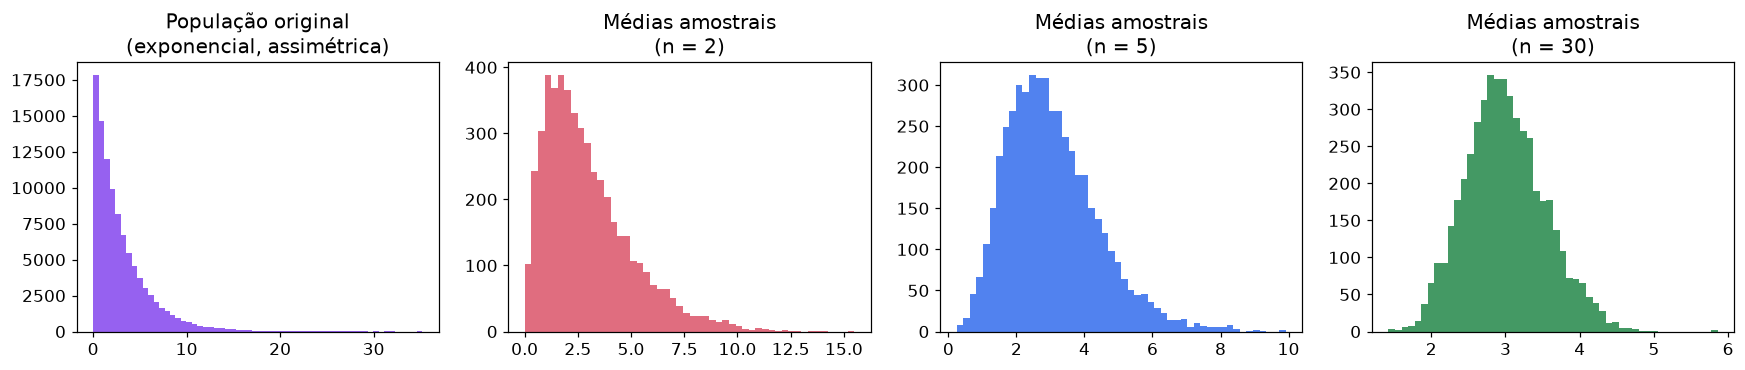

In [4]:
# ── Visualização: população x distribuição das médias ───────────
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))

axes[0].hist(populacao, bins=60, color='#7c3aed', alpha=.8)
axes[0].set_title('População original\n(exponencial, assimétrica)')

cores = ['#d9485f', '#2563eb', '#15803d']
for ax, n, cor in zip(axes[1:], tamanhos, cores):
    ax.hist(medias_por_n[n], bins=50, color=cor, alpha=.8)
    ax.set_title(f'Médias amostrais\n(n = {n})')

plt.tight_layout()
plt.show()
# Quanto maior o n, mais a distribuição das médias se aproxima do formato de sino

---
## 2 · Exemplo 2 — Erro Padrão e Intervalo de Confiança para a Média
### Problema: qual é o ticket médio de compra, com que margem de confiança?

**Erro padrão:** `EP(x̄) = s / √n` — mede a variabilidade esperada da média amostral.

**Intervalo de confiança:** `estimativa ± valor crítico × erro padrão`. Com poucas observações (n pequeno), usamos a distribuição **t** de Student em vez do z.

In [5]:
# ── Amostra: ticket de 10 compras (R$) ──────────────────────────
ticket = np.array([175, 168, 190, 201, 185,
                    178, 194, 183, 176, 188])

media = ticket.mean()
desvio = ticket.std(ddof=1)     # ddof=1 -> desvio-padrão AMOSTRAL
n = len(ticket)
erro_padrao = desvio / np.sqrt(n)

print(f'Média amostral:  R$ {media:.2f}')
print(f'Desvio amostral: R$ {desvio:.2f}')
print(f'Erro padrão:     R$ {erro_padrao:.2f}')

Média amostral:  R$ 183.80
Desvio amostral: R$ 9.89
Erro padrão:     R$ 3.13


In [6]:
# ── Intervalo de confiança de 95% usando a distribuição t ───────
ic = stats.t.interval(
    confidence=0.95,
    df=n - 1,                 # graus de liberdade
    loc=media,
    scale=erro_padrao
)

print(f'IC 95%: [R$ {ic[0]:.2f} ; R$ {ic[1]:.2f}]')
print(f'Margem de erro: ± R$ {(ic[1]-ic[0])/2:.2f}')

# ── O que acontece se a amostra quadruplicar (de 10 para 40)? ───
# Mantendo o mesmo desvio, o erro padrão cai pela metade (√4 = 2)
ep_maior_amostra = desvio / np.sqrt(n * 4)
print(f'\nSe n fosse {n*4}: erro padrão cairia de R$ {erro_padrao:.2f} para R$ {ep_maior_amostra:.2f}')

IC 95%: [R$ 176.73 ; R$ 190.87]
Margem de erro: ± R$ 7.07

Se n fosse 40: erro padrão cairia de R$ 3.13 para R$ 1.56


---
## 3 · Exemplo 3 — Intervalo de Confiança para Proporção
### Problema: qual a taxa de satisfação (NPS) dos clientes?

**Fórmula:** `p̂ ± 1,96 × √(p̂(1−p̂)/n)` para 95% de confiança.

> **Cuidado com a interpretação:** o IC de 95% NÃO significa "95% de chance de p estar no intervalo". Significa que, repetindo o processo de amostragem muitas vezes, 95% dos intervalos construídos conteriam o verdadeiro parâmetro.

In [7]:
# ── Pesquisa de satisfação: 200 clientes, 130 promotores ────────
promotores = 130
total = 200
p_hat = promotores / total

ic = proportion_confint(promotores, total, alpha=0.05, method='normal')

print(f'Proporção amostral (p̂): {p_hat:.3f}')
print(f'IC 95%: [{ic[0]:.3f} ; {ic[1]:.3f}]')
print(f'Em porcentagem: [{ic[0]*100:.1f}% ; {ic[1]*100:.1f}%]')

Proporção amostral (p̂): 0.650
IC 95%: [0.584 ; 0.716]
Em porcentagem: [58.4% ; 71.6%]


In [8]:
# ── Como a margem de erro cai conforme a amostra cresce ─────────
amostras = [50, 100, 200, 400, 1000, 2000]
print(f'{"n":>6} | {"margem (95%)":>14}')
for na in amostras:
    lo, hi = proportion_confint(round(p_hat * na), na, alpha=0.05, method='normal')
    margem = (hi - lo) / 2
    print(f'{na:>6} | ±{margem*100:>12.1f}%')
# Regra prática: para reduzir a margem pela metade, é preciso quadruplicar o n

     n |   margem (95%)
    50 | ±        13.3%
   100 | ±         9.3%
   200 | ±         6.6%
   400 | ±         4.7%
  1000 | ±         3.0%
  2000 | ±         2.1%


---
## 4 · Exemplo 4 — Teste t de Duas Amostras Independentes
### Problema: o novo processo de atendimento (equipe B) é mais rápido que o antigo (equipe A)?

**H₀:** tempo médio de A = tempo médio de B
**H₁:** tempo médio de A ≠ tempo médio de B

In [9]:
# ── Dados: tempo de atendimento (minutos) ───────────────────────
np.random.seed(42)
equipe_a = np.random.normal(9.2, 1.8, 40)
equipe_b = np.random.normal(8.5, 2.1, 42)

# 1. Verificar igualdade de variâncias (teste de Levene)
_, p_levene = stats.levene(equipe_a, equipe_b)
variancias_iguais = p_levene > 0.05
print(f'Variâncias iguais? {variancias_iguais} (p = {p_levene:.3f})')

# 2. Teste t (usa Welch automaticamente se variâncias forem diferentes)
t_stat, p_valor = stats.ttest_ind(equipe_a, equipe_b, equal_var=variancias_iguais)
print(f't = {t_stat:.3f}, p = {p_valor:.4f}')
print('Rejeitar H0?', 'Sim' if p_valor < 0.05 else 'Não')

Variâncias iguais? True (p = 0.451)
t = 0.872, p = 0.3857
Rejeitar H0? Não


Diferença de médias: 0.36 min
Cohen's d: 0.193


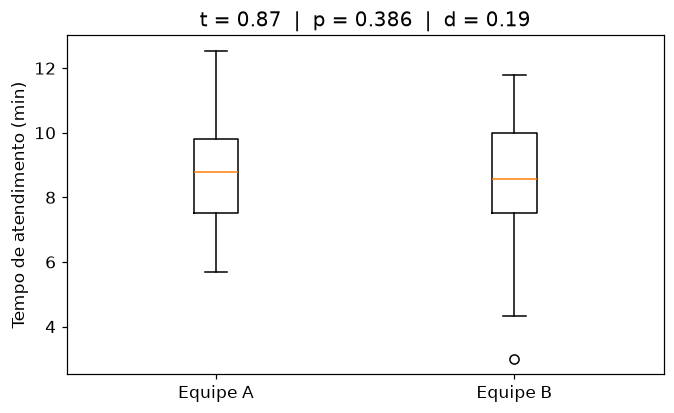

In [11]:
# ── Cohen's d: significância estatística != relevância prática ──
s_pool = np.std(np.concatenate([equipe_a, equipe_b]), ddof=1)
d = (equipe_a.mean() - equipe_b.mean()) / s_pool

print(f'Diferença de médias: {equipe_a.mean() - equipe_b.mean():.2f} min')
print(f"Cohen's d: {d:.3f}")
# |d| < 0.2 -> pequeno | ~0.5 -> médio | >= 0.8 -> grande

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([equipe_a, equipe_b])
ax.set_xticklabels(['Equipe A', 'Equipe B'])
ax.set_ylabel('Tempo de atendimento (min)')
ax.set_title(f't = {t_stat:.2f}  |  p = {p_valor:.3f}  |  d = {d:.2f}')
plt.show()

---
## 5 · Exemplo 5 — Teste t Pareado (Antes/Depois)
### Problema: o treinamento reduziu o tempo de atendimento do MESMO colaborador?

Quando as duas medições vêm do **mesmo indivíduo** (antes e depois), usamos o teste **pareado** — ele é mais sensível porque remove a variação entre pessoas.

In [12]:
# ── Dados: mesmo colaborador, medido antes e depois do treinamento
np.random.seed(1)
antes = np.random.normal(10, 2, 30)
depois = antes - np.random.normal(1, 0.5, 30)   # melhora individual consistente

t_stat, p_valor = stats.ttest_rel(antes, depois)
diferenca_media = (antes - depois).mean()

print(f'Redução média: {diferenca_media:.2f} min')
print(f't = {t_stat:.3f}, p = {p_valor:.4f}')
print('Rejeitar H0?', 'Sim' if p_valor < 0.05 else 'Não')
# Teste pareado tende a detectar o efeito com mais facilidade que o teste independente

Redução média: 1.04 min
t = 13.472, p = 0.0000
Rejeitar H0? Sim


---
## 6 · Exemplo 6 — ANOVA Unidirecional + Post-hoc Tukey HSD
### Problema: existe diferença de receita média entre os canais Email, App e Loja Física?

A ANOVA só diz **se existe** diferença entre 3 ou mais grupos. O Tukey HSD identifica **quais pares** diferem, controlando o erro acumulado de múltiplos testes.

In [13]:
# ── Dados: receita média (R$) por canal ──────────────────────────
np.random.seed(7)
email = np.random.normal(320, 60, 50)
app   = np.random.normal(380, 75, 50)
loja  = np.random.normal(290, 55, 50)

# ── ANOVA one-way ────────────────────────────────────────────────
F, p_valor = stats.f_oneway(email, app, loja)
print(f'F = {F:.2f}, p = {p_valor:.4f}')
print('Existe diferença entre os canais?', 'Sim' if p_valor < 0.05 else 'Não')

F = 39.88, p = 0.0000
Existe diferença entre os canais? Sim


  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj    lower    upper   reject
--------------------------------------------------------
   App  Email  -74.4174    0.0 -103.8199 -45.0149   True
   App   Loja -108.4264    0.0 -137.8289  -79.024   True
 Email   Loja   -34.009 0.0189  -63.4115  -4.6065   True
--------------------------------------------------------


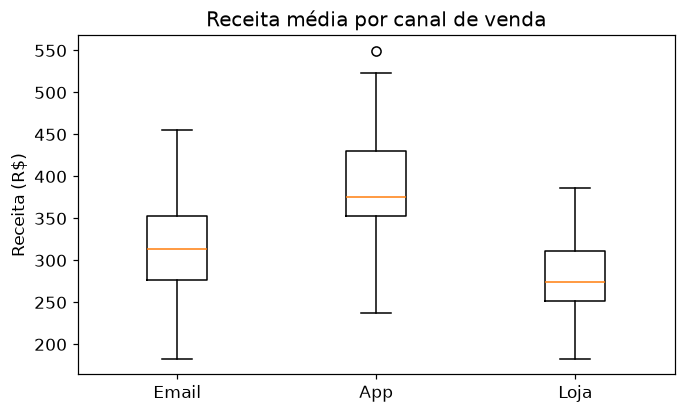

In [15]:
# ── Post-hoc: quais pares diferem? ───────────────────────────────
dados = np.concatenate([email, app, loja])
grupos = ['Email'] * 50 + ['App'] * 50 + ['Loja'] * 50

resultado = pairwise_tukeyhsd(dados, grupos)
print(resultado)

fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([email, app, loja])
ax.set_xticklabels(['Email', 'App', 'Loja'])
ax.set_ylabel('Receita (R$)')
ax.set_title('Receita média por canal de venda')
plt.show()
# App gera a maior receita média -> candidato a receber mais investimento

---
## 7 · Exemplo 7 — Qui-Quadrado de Independência
### Problema: o canal de aquisição e o churn do cliente estão relacionados?

Usamos uma **tabela de contingência**: linhas = canal, colunas = status (ativo/churn).

In [16]:
# ── Tabela de contingência: canal x status ───────────────────────
tabela = np.array([
    [210, 90],   # Email         -> [ativos, churn]
    [180, 70],   # Redes Sociais
    [160, 90],   # Orgânico
])

chi2, p_valor, graus_liberdade, esperado = stats.chi2_contingency(tabela)
print(f'chi2 = {chi2:.3f}')
print(f'p    = {p_valor:.4f}')
print(f'gl   = {graus_liberdade}')
print('Canal e churn são independentes?', 'Não' if p_valor < 0.05 else 'Sim')

chi2 = 4.073
p    = 0.1305
gl   = 2
Canal e churn são independentes? Sim


In [17]:
# ── Resíduos padronizados: quem contribui mais para a associação? ─
observado = tabela.astype(float)
residuos = (observado - esperado) / np.sqrt(esperado)

canais = ['Email', 'Redes Sociais', 'Orgânico']
df_residuos = pd.DataFrame(residuos, index=canais, columns=['Ativo', 'Churn'])
print('Resíduos padronizados (> |2| chama atenção):')
df_residuos.round(2)
# Clientes orgânicos têm o maior resíduo em churn -> investigar o onboarding desse perfil

Resíduos padronizados (> |2| chama atenção):


,Ativo,Churn
Email,0.26,-0.39
Redes Sociais,0.62,-0.92
Orgânico,-0.91,1.34


---
## 8 · Exemplo 8 — Teste A/B de Proporções + Poder Estatístico
### Problema: a variante B do site converte mais do que o controle A?

**H₀:** taxa_B = taxa_A
**H₁:** taxa_B > taxa_A

In [18]:
# ── Dados do teste A/B ───────────────────────────────────────────
conversoes = np.array([320, 377])   # [controle A, variante B]
usuarios   = np.array([4000, 4100])

z_stat, p_valor = proportions_ztest(conversoes, usuarios, alternative='smaller')
print(f'z = {z_stat:.3f}')
print(f'p = {p_valor:.4f}')
print('B converte significativamente mais que A?', 'Sim' if p_valor < 0.05 else 'Não')

# ── Intervalo de confiança de cada taxa ──────────────────────────
for conv, n in zip(conversoes, usuarios):
    lo, hi = proportion_confint(conv, n, alpha=0.05)
    print(f'Taxa = {conv/n:.3f}  IC95% = [{lo:.3f}, {hi:.3f}]')

z = -1.918
p = 0.0276
B converte significativamente mais que A? Sim
Taxa = 0.080  IC95% = [0.072, 0.088]
Taxa = 0.092  IC95% = [0.083, 0.101]


In [19]:
# ── Poder estatístico: o experimento tinha chance real de detectar o efeito? ──
analise = TTestIndPower()

# Quantos usuários por grupo seriam necessários para 80% de poder,
# assumindo um efeito médio (Cohen's d = 0.5)?
n_necessario = analise.solve_power(effect_size=0.5, alpha=0.05, power=0.80)
print(f'n necessário por grupo (d=0.5, poder=80%): {n_necessario:.0f}')

# Qual o poder real do experimento, com o efeito observado?
taxa_a, taxa_b = conversoes[0]/usuarios[0], conversoes[1]/usuarios[1]
d_observado = (taxa_b - taxa_a) / np.sqrt(taxa_a * (1 - taxa_a))
poder_real = analise.power(effect_size=d_observado, nobs1=usuarios[0], alpha=0.05)
print(f'Poder estimado do experimento atual: {poder_real:.1%}')
# Estudar o poder ANTES de rodar o teste evita gastar tempo sem chance real de detectar o efeito

n necessário por grupo (d=0.5, poder=80%): 64
Poder estimado do experimento atual: 50.4%


---
## 9 · Mapa Rápido de Testes

| Pergunta | Teste | Exemplo neste notebook |
|---|---|---|
| Comparar uma média com referência | t de 1 amostra | — |
| Comparar médias de 2 grupos independentes | t de 2 amostras | Exemplo 4 (equipes A/B) |
| Comparar médias antes/depois (mesmo grupo) | t pareado | Exemplo 5 (antes/depois) |
| Comparar 3 ou mais grupos | ANOVA | Exemplo 6 (canais de venda) |
| Associação entre categorias | Qui-quadrado | Exemplo 7 (canal × churn) |
| Comparar proporções entre grupos | Teste de proporções (z) | Exemplo 8 (teste A/B) |

> Requisitos de t e ANOVA: normalidade (ou n grande, pelo TCL) e independência entre observações. Para amostras pequenas sem normalidade, use testes não-paramétricos (Mann-Whitney, Kruskal-Wallis).

---
## 10 · EXERCÍCIO — Sua Vez!

Agora é sua vez de aplicar o que foi mostrado nos exemplos. Resolva os três cenários abaixo usando os métodos vistos nas seções anteriores.

### Exercício 1 — Teste t de duas amostras (a partir de estatísticas resumidas)

Uma empresa comparou o tempo de atendimento **antes** e **depois** de um novo processo (grupos independentes, não pareados):

| Grupo | n | Média (min) | Desvio-padrão |
|---|---|---|---|
| Antes | 35 | 9,8 | 2,1 |
| Depois | 38 | 8,9 | 1,9 |

**Tarefas:**
1. Defina H₀ e H₁.
2. Calcule o teste t usando `stats.ttest_ind_from_stats` (não temos os dados brutos, só o resumo).
3. Interprete: o novo processo é significativamente mais rápido?

In [25]:
# ── TAREFA: Exercício 1 ──────────────────────────────────────────
# Dica: stats.ttest_ind_from_stats(mean1, std1, nobs1, mean2, std2, nobs2)

media_antes, desvio_antes, n_antes = 9.8, 2.1, 35
media_depois, desvio_depois, n_depois = 8.9, 1.9, 38

# Seu código aqui:

# 01:
print('1. Defina H₀ e H₁:')
print('H0 (Hipótese Nula): O tempo médio de atendimento antes e depois é igual (média_antes = média_depois)')
print('H1 (Hipótese Alternativa): O tempo médio de atendimento é diferente (média_antes != média_depois)')

# 02:
print('\n2. Calcule o teste t usando `stats.ttest_ind_from_stats` (não temos os dados brutos, só o resumo):')
t_stat, p_valor = stats.ttest_ind_from_stats(
    mean1=media_antes, std1=desvio_antes, nobs1=n_antes,
    mean2=media_depois, std2=desvio_depois, nobs2=n_depois,
    equal_var=False  # Usamos False por precaução (teste de Welch, não assume variâncias iguais)
)
print(f"Estatística t: {t_stat:.3f}")
print(f"Valor-p (p-value): {p_valor:.4f}")

# 03:
print('\n3. Interprete: o novo processo é significativamente mais rápido?')
alpha = 0.05
if p_valor < alpha:
    print("Rejeitar H0? Sim. O novo processo é significativamente mais rápido.")
else:
    print("Rejeitar H0? Não. Não há evidência estatística suficiente para afirmar que o tempo mudou.")

1. Defina H₀ e H₁:
H0 (Hipótese Nula): O tempo médio de atendimento antes e depois é igual (média_antes = média_depois)
H1 (Hipótese Alternativa): O tempo médio de atendimento é diferente (média_antes != média_depois)

2. Calcule o teste t usando `stats.ttest_ind_from_stats` (não temos os dados brutos, só o resumo):
Estatística t: 1.914
Valor-p (p-value): 0.0597

3. Interprete: o novo processo é significativamente mais rápido?
Rejeitar H0? Não. Não há evidência estatística suficiente para afirmar que o tempo mudou.


### Exercício 2 — Intervalo de Confiança para Proporção

Uma pesquisa de satisfação teve **300 respostas**, das quais **192 clientes se disseram satisfeitos**.

**Tarefas:**
1. Calcule o IC de 95% para a taxa de satisfação.
2. Diga se a meta de **60% de satisfação** é atingida (ou seja, se 0,60 está dentro ou fora do intervalo).

In [28]:
# ── TAREFA: Exercício 2 ──────────────────────────────────────────
satisfeitos = 192
total_respostas = 300
meta = 0.60

# Seu código aqui:

# 01:
print('1. Calcule o IC de 95% para a taxa de satisfação:')
ic = proportion_confint(count=satisfeitos, nobs=total_respostas, alpha=0.05, method='normal')
p_hat = satisfeitos / total_respostas
print(f"Proporção amostral (p̂): {p_hat:.3f} ({p_hat*100:.1f}%)")
print(f"IC 95%: [{ic[0]:.3f} ; {ic[1]:.3f}]  ->  [{ic[0]*100:.1f}% ; {ic[1]*100:.1f}%]")

# 02:
print('\n2. Diga se a meta de **60% de satisfação** é atingida (ou seja, se 0,60 está dentro ou fora do intervalo):')
atingiu_meta = ic[0] <= meta <= ic[1]
if atigiu_meta if 'atigiu_meta' in locals() else ic[0] <= meta <= ic[1]:
    print(f"A meta de {meta*100}% está DENTRO do intervalo de confiança.")
else:
    print(f"A meta de {meta*100}% está FORA do intervalo de confiança.")

1. Calcule o IC de 95% para a taxa de satisfação:
Proporção amostral (p̂): 0.640 (64.0%)
IC 95%: [0.586 ; 0.694]  ->  [58.6% ; 69.4%]

2. Diga se a meta de **60% de satisfação** é atingida (ou seja, se 0,60 está dentro ou fora do intervalo):
A meta de 60.0% está DENTRO do intervalo de confiança.


### Exercício 3 — Qui-Quadrado de Independência

Uma empresa de assinaturas quer saber se o **plano** está relacionado à **retenção**:

| Plano | Renovam | Cancelam |
|---|---|---|
| Básico | 80 | 120 |
| Premium | 150 | 50 |

**Tarefas:**
1. Monte a tabela de contingência.
2. Calcule o teste qui-quadrado.
3. Conclua: plano e retenção são independentes?

In [36]:
# ── TAREFA: Exercício 3 ──────────────────────────────────────────
tabela_planos = np.array([
    [80, 120],    # Básico  -> [renovam, cancelam]
    [150, 50],    # Premium
])

# Seu código aqui:

# 01:
print('1. Monte a tabela de contingência:')
tabela_planos_df = pd.DataFrame(
    tabela_planos,  # <--- Usando a variável original aqui
    index=['Básico', 'Premium'], 
    columns=['Renovam', 'Cancelam']
)
print(tabela_planos_df)

# 02:
print('\n2. Calcule o teste qui-quadrado:')
chi2, p_valor, graus_liberdade, esperado = stats.chi2_contingency(tabela_planos)
print(f"Estatística Chi2 = {chi2:.3f}")
print(f"Valor-p (p-value) = {p_valor:.4e}")
print(f"Graus de liberdade (gl) = {graus_liberdade}")

# 03:
print('\n3. Conclua: plano e retenção são independentes?')
alpha = 0.05
if p_valor < alpha:
    print("Plano e retenção são independentes? Não. Existe associação estatisticamente significativa entre o plano e a retenção.")
else:
    print("Plano e retenção são independentes? Sim. Não há evidência suficiente de associação.")

1. Monte a tabela de contingência:
         Renovam  Cancelam
Básico        80       120
Premium      150        50

2. Calcule o teste qui-quadrado:
Estatística Chi2 = 48.706
Valor-p (p-value) = 2.9737e-12
Graus de liberdade (gl) = 1

3. Conclua: plano e retenção são independentes?
Plano e retenção são independentes? Não. Existe associação estatisticamente significativa entre o plano e a retenção.


---
### Perguntas para reflexão

Responda nas células abaixo (texto livre — clique duas vezes para editar):

**1.** No Exercício 1, mesmo que o resultado seja estatisticamente significativo (ou não), como você avaliaria a **relevância prática** da diferença de tempo?

> *Uma diferença estatisticamente significativa pode ser irrelevante se o ganho real for insignificante para o negócio.*

**2.** No Exercício 2, por que NÃO é correto dizer "há 95% de chance de a taxa real estar nesse intervalo"? Qual é a interpretação correta?

> *Significa que, se repetirmos a amostragem muitas vezes, $95\%$ dos intervalos construídos conterão o verdadeiro parâmetro populacional (que é fixo).*

**3.** No Exercício 3, se a empresa decidir agir com base no resultado do qui-quadrado, que ação de negócio você recomendaria?

> *Investigar os motivos de cancelamento no plano básico e criar campanhas para migrar esses clientes para o plano Premium.*

---
**Ciência de Dados · Aula 05 · Prof. Mesc. Diego Ramos Inácio · Univassouras · 2026**